# **KÜTÜPHANELER VE GENEL BAKIŞ**

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA


In [6]:
# Veri seti yükleme
df = pd.read_csv('/content/sample_data/ultimate_video_game_industry_dataset_v3_20000.csv')

sayisal_sutunlar = ["budget_million_usd","metacritic_score","user_score","estimated_revenue_million"]
kategorik_sutunlar = ["developer_size","genre","goty_award"]

print(f"Veri seti: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head()

Veri seti: 20000 satır, 32 sütun


,game_id,title,franchise,developer,publisher,developer_size,development_years,budget_million_usd,release_date,release_year,...,completionist_hours,game_size_gb,minimum_ram_gb,recommended_ram_gb,vr_support,ray_tracing,goty_award,award_count,nomination_count,commercial_success
0,1,Minecraft 1,Minecraft,Andrews-Nelson,"Griffith, James and Turner",Indie,3.3,2.15,1993-08-12,1993,...,13.2,13.1,4,8,0,0,0,0,2,Average
1,2,Stardew Valley 19,Stardew Valley,"Marsh, Rios and Fox",Moore LLC,AAA,1.1,299.73,1991-06-11,1991,...,12.7,60.5,4,8,0,0,0,0,6,Blockbuster
2,3,Cyberpunk 11,Cyberpunk,Rojas LLC,Rodriguez Inc,Indie,1.6,3.82,2013-01-09,2013,...,15.8,46.4,8,8,0,0,0,1,1,Average
3,4,Halo 1,Halo,Brown LLC,Davidson-Thompson,AAA,5.8,189.98,2008-05-11,2008,...,50.3,85.9,8,8,0,0,0,0,1,Blockbuster
4,5,Minecraft 14,Minecraft,"Anthony, Alvarado and Thompson","Williamson, Oconnell and Cruz",AAA,5.3,209.44,1995-02-02,1995,...,78.9,64.8,4,8,0,0,0,0,6,Blockbuster


In [7]:
# Genel Özet Tablosu
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer":df.isnull().sum(),
    "eksik_deger_yuzdesi": (df.isnull().mean()*100).round(2)
})

ozet.head(10)

,dtype,n_unique,eksik_değer,eksik_deger_yuzdesi
game_id,int64,20000,0,0.0
title,object,1006,0,0.0
franchise,object,20,0,0.0
developer,object,16309,0,0.0
publisher,object,16308,0,0.0
developer_size,object,3,0,0.0
development_years,float64,61,0,0.0
budget_million_usd,float64,10239,0,0.0
release_date,object,10424,0,0.0
release_year,int64,37,0,0.0


In [8]:
# Tekrar eden satır kontrolü ve metin temizliği
print("Tekrar eden satır sayısı:", df.duplicated().sum())
df["genre"] = df["genre"].str.strip().str.title()
print(df["genre"].value_counts())

Tekrar eden satır sayısı: 0
genre
Fps           2076
Simulation    2059
Rpg           2052
Horror        2031
Racing        2020
Strategy      2006
Sports        2004
Sandbox       1921
Action        1919
Adventure     1912
Name: count, dtype: int64


# **# BETİMSEL İSTATİSTİK VE GÜVEN ARALIĞI**

In [9]:
"""Örneklem ortalamasının t-dağılımı ve standart hata (sem)
 kullanılarak %95 güven sınırları hesaplanır: """
def ortalama_guven_araligi(seri, guven=0.95):
    veri = seri.dropna()
    n = len(veri)
    ortalama = veri.mean()
    sem = stats.sem(veri)
    t_kritik = stats.t.ppf((1 + guven) / 2, df=n - 1)
    hata_payi = t_kritik * sem
    return ortalama, ortalama - hata_payi, ortalama + hata_payi

print(f"{'Değişken':28s} {'Ortalama':>12s} {'%95 Alt':>12s} {'%95 Üst':>12s}")
for degisken in sayisal_sutunlar:
    ortalama, alt, ust = ortalama_guven_araligi(df[degisken])
    print(f"{degisken:28s} {ortalama:>12.2f} {alt:>12.2f} {ust:>12.2f}")


Değişken                         Ortalama      %95 Alt      %95 Üst
budget_million_usd                  85.42        83.93        86.91
metacritic_score                    78.66        78.54        78.79
user_score                           7.87         7.85         7.88
estimated_revenue_million         1148.96      1130.81      1167.12


In [10]:
# Betimsel Tablo + Çarpıklık (Skewness) + Basıklık (Kurtosis)
betimsel = df[sayisal_sutunlar].describe().T
betimsel["skew"] = df[sayisal_sutunlar].skew()
betimsel["kurtosis"] = df[sayisal_sutunlar].kurtosis()
betimsel.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
budget_million_usd,20000.0,85.42,107.30,0.20,3.62,26.12,159.89,349.99,1.08,-0.29
metacritic_score,20000.0,78.66,8.74,48.00,73.00,79.00,85.00,99.00,-0.06,-0.26
user_score,20000.0,7.87,0.90,4.40,7.20,7.90,8.50,10.00,-0.06,-0.26
estimated_revenue_million,20000.0,1148.96,1310.02,7.35,79.75,423.10,2110.26,7050.69,1.08,0.28


## **Normallik Testleri ve Q-Q Grafikleri**

In [11]:
print(f"{'Değişken':28s} {'Shapiro-Wilk p':>16s} {'DAgostino p':>14s} Yorum")
for col in sayisal_sutunlar:
    veri = df[col].dropna()
    #shapiro n>5000 den fazla olursa veri güvenilmez olur.
    ornek = veri.sample(min(len(veri), 5000), random_state=0)
    sw_stat, sw_p = stats.shapiro(ornek)
    da_stat, da_p = stats.normaltest(veri)
    yorum = "Normal dağılım sağlanmaktadır." if sw_p > 0.05 else "Normal dağılım sağlanmamaktadır."
    print(f"{col:28s} {sw_p:>16.16f} {da_p:>14.21f} {yorum}")

Değişken                       Shapiro-Wilk p    DAgostino p Yorum
budget_million_usd           0.0000000000000000 0.000000000000000000000 Normal dağılım sağlanmamaktadır.
metacritic_score             0.0000000000672066 0.000000000000000000270 Normal dağılım sağlanmamaktadır.
user_score                   0.0000000007474021 0.000000000000000000103 Normal dağılım sağlanmamaktadır.
estimated_revenue_million    0.0000000000000000 0.000000000000000000000 Normal dağılım sağlanmamaktadır.


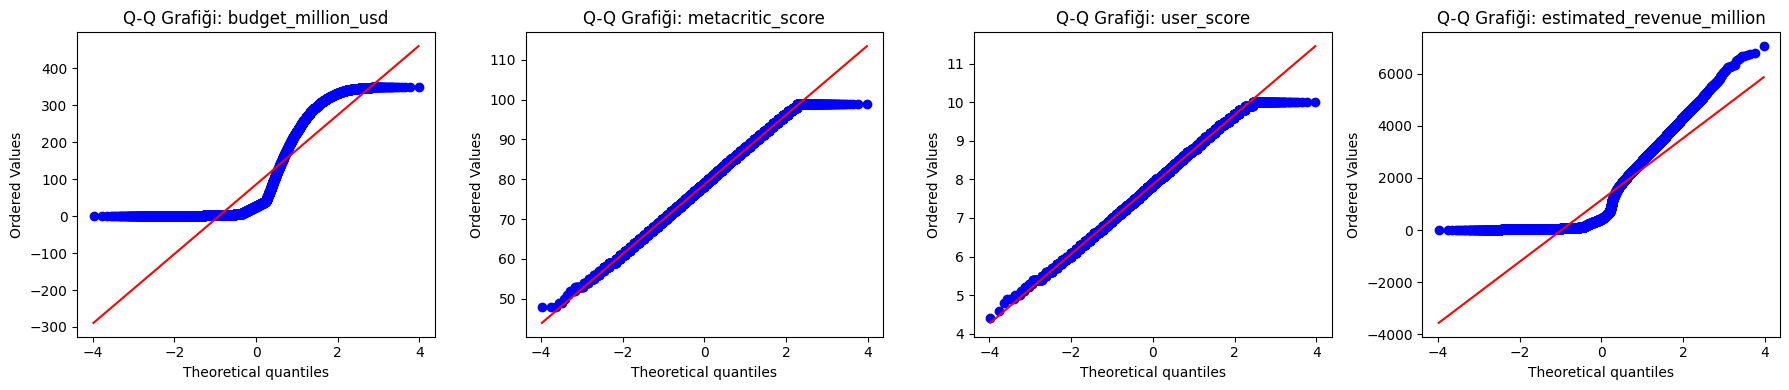

In [12]:
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(18, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

## **İki Bağımsız Grup Karşılaştırması**
GOTY ödülü kazanan (goty_award=1) ve kazanamayan (goty_award=0) oyunların eleştirmen puanları (metacritic_score) karşılaştırılır:

In [17]:
grup0= df.loc[df["goty_award"] == 0 , "metacritic_score"].dropna()
grup1 = df.loc[df["goty_award"] == 1, "metacritic_score"].dropna()

# Levene homojenlik testi
levene_stat, levene_p = stats.levene(grup0, grup1)
print("Varsayımlar (Varyanslar) homojendir." if levene_p > 0.05 else "Varsayımlar(Varyanslar) homojen değildir.")

# Normallik kontrolü
__, p0=stats.shapiro(grup0.sample(min(len(grup0),5000),random_state=0))
__, p1=stats.shapiro(grup1.sample(min(len(grup1),5000),random_state=0))
normal_mi = (p0>0.05) and (p1>0.05)
print(f"grup normallik p değerleri: goty=0 -> {p0:.8f},goty=1 -> {p1:.8f}\n")

# Parametrik olmayan (Mann-Whitney U) & Parametrik (Welch t-test)
u_stat, u_p = stats.mannwhitneyu(grup0, grup1)
t_stat, t_p = stats.ttest_ind(grup0, grup1, equal_var=False)
print(f"Mann-Whitney U Testi: Stat={u_stat:.2f}, p-değeri={u_p:.4e}\n")
print(f"Welch t-testi: t={t_stat:.2f}, p-değeri={t_p:.4e}")
print(f"Ortalamalar -> GOTY=0: {grup0.mean():.2f}, GOTY=1: {grup1.mean():.2f}")


Varsayımlar(Varyanslar) homojen değildir.
grup normallik p değerleri: goty=0 -> 0.00000000,goty=1 -> 0.00000000

Mann-Whitney U Testi: Stat=36485.50, p-değeri=0.0000e+00

Welch t-testi: t=-207.60, p-değeri=0.0000e+00
Ortalamalar -> GOTY=0: 77.93, GOTY=1: 96.56


# **çoklu grup karşılaştırması**
Stüdyo ölçeğine göre (developer_size: AAA, AA, Indie) oyunların tahmini gelirleri (estimated_revenue_million) analiz edilir:

In [19]:
# Anova
gruplar = [g["estimated_revenue_million"].dropna().values for _, g in df.groupby("developer_size")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p = stats.kruskal(*gruplar)

print(f"Tek Yönlü ANOVA: F = {f_stat:.3f}, p = {anova_p:.4e}")
print(f"Kruskal-Wallis:  H = {h_stat:.3f}, p = {kw_p:.4e}")

Tek Yönlü ANOVA: F = 33643.983, p = 0.0000e+00
Kruskal-Wallis:  H = 17490.178, p = 0.0000e+00


In [20]:
# Etki Büyüklüğü (Eta-Kare)
genel_ortalama = df["estimated_revenue_million"].mean()
ss_between = sum(len(g) * (g.mean() - genel_ortalama) ** 2 for g in gruplar)
ss_total = sum((df["estimated_revenue_million"].dropna() - genel_ortalama) ** 2)
eta_kare = ss_between / ss_total
print(f"Eta Kare: {eta_kare:.4f} (0.01 küçük, 0.06 orta, 0.14 büyük etki)")

#Sonuç: $\eta^2 = 0.7709$ çıkmaktadır; yani oyun gelirindeki varyansın yaklaşık %77'si stüdyo büyüklüğü (developer size) ile açıklanır.

Eta Kare: 0.7709 (0.01 küçük, 0.06 orta, 0.14 büyük etki)


In [21]:
# Post-Hoc Tukey HSD Testi
tukey = pairwise_tukeyhsd(
    endog=df["estimated_revenue_million"].dropna(),
    groups=df.loc[df["estimated_revenue_million"].notna(), "developer_size"],
    alpha=0.05
)
print(tukey)

    Multiple Comparison of Means - Tukey HSD, FWER=0.05    
group1 group2  meandiff  p-adj   lower      upper    reject
-----------------------------------------------------------
    AA    AAA  2129.7217   0.0  2103.1381  2156.3054   True
    AA  Indie   -338.446   0.0  -365.8097  -311.0822   True
   AAA  Indie -2468.1677   0.0 -2492.1621 -2444.1734   True
-----------------------------------------------------------


## Kategorik Değişkenler Arasındaki İlişki

In [22]:
# Stüdyo büyüklüğü ile GOTY kazanma olasılığı arasındaki ilişki
def cramers_v(x, y):
    tablo = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(tablo)[0]
    n = tablo.sum().sum()
    k = min(tablo.shape) - 1
    return np.sqrt(chi2 / (n * k))

capraz = pd.crosstab(df["developer_size"], df["goty_award"])
chi2, p, dof, beklenen = stats.chi2_contingency(capraz)
v = cramers_v(df["developer_size"], df["goty_award"])

print(f"Chi2 = {chi2:.4f}, p = {p:.4e}, df = {dof}")
print(f"Cramer's V: {v:.4f}")
print("\nÇapraz Tablo:\n", capraz)

Chi2 = 590.3085, p = 6.5483e-129, df = 2
Cramer's V: 0.1718

Çapraz Tablo:
 goty_award         0    1
developer_size           
AA              4746  165
AAA             7475  621
Indie           6993    0


## **Korelasyon Analizi**



In [28]:
#Pearson Korelasyon Katsayıları ve Korelasyon Matrisi
def korelasyon_p_matrisi(veri, yontem="pearson"):
    sutunlar = veri.columns
    kat = pd.DataFrame(np.ones((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
    pval = pd.DataFrame(np.zeros((len(sutunlar), len(sutunlar))), index=sutunlar, columns=sutunlar)
    for i in sutunlar:
        for j in sutunlar:
            if i == j:
                continue
            ortak = veri[[i, j]].dropna()
            r, p = stats.pearsonr(ortak.iloc[:, 0],ortak.iloc[:, 1]) if yontem == "pearson" else stats.spearmanr(ortak.iloc[:, 0], ortak.iloc[:, 1])
            kat.loc[i, j] = float(r)
            pval.loc[i, j] = float(p)
    return kat, pval

pearson_r, pearson_p = korelasyon_p_matrisi(df[sayisal_sutunlar], "pearson")
print("--- Pearson Korelasyon Katsayıları ---")
print(pearson_r.round(3))

--- Pearson Korelasyon Katsayıları ---
                           budget_million_usd  metacritic_score  user_score  \
budget_million_usd                      1.000             0.228       0.217   
metacritic_score                        0.228             1.000       0.966   
user_score                              0.217             0.966       1.000   
estimated_revenue_million               0.745             0.498       0.478   

                           estimated_revenue_million  
budget_million_usd                             0.745  
metacritic_score                               0.498  
user_score                                     0.478  
estimated_revenue_million                      1.000  


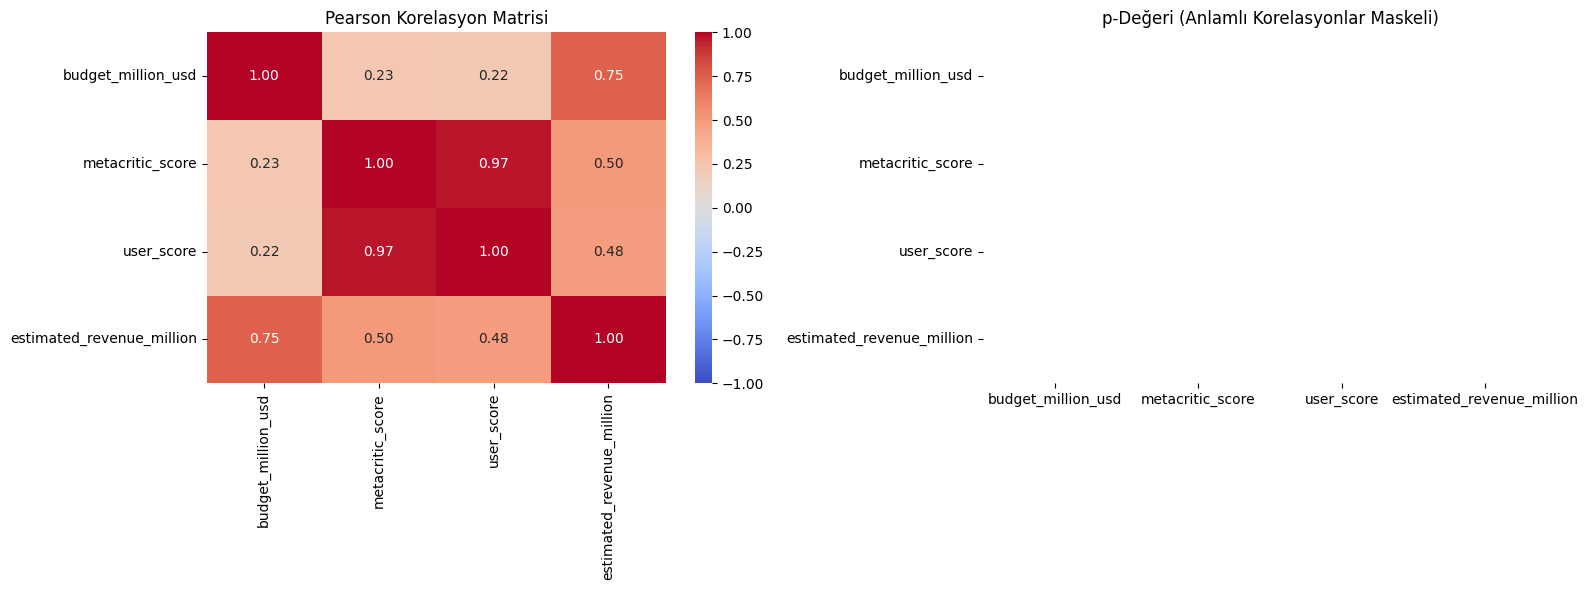

In [30]:
# Korelasyon Isı Haritası (Anlamlılık Maskesi ile)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(pearson_r, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, ax=axes[0])
axes[0].set_title("Pearson Korelasyon Matrisi")

anlamli_maske = pearson_p > 0.05
sns.heatmap(pearson_p, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1, mask=~anlamli_maske, ax=axes[1], cbar=False)
axes[1].set_title("p-Değeri (Anlamlı Korelasyonlar Maskeli)")

plt.tight_layout()
plt.show()

## **Çoklu Doğrusal Bağlantı(Multicollinerity)**


* VIF < 5 sorun yoktur.

* 5 <VIF<10 dikkat edilmeli.

* VIF>10 barajı aşmıştır bir sorun teşkil eder.

In [31]:
X_vif = df[["budget_million_usd", "metacritic_score", "user_score"]].dropna()
X_vif = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": [X_vif.columns[i] for i in range(1, X_vif.shape[1])],
    "VIF": [VIF(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})
print(vif_tablosu)
"""Not: metacritic_score ile user_score arasındaki korelasyon $r = 0.966$ olduğundan VIF 10 barajını aşmıştır.
   Bu iki değişkenden birisi (örneğin user_score) modelden çıkarılarak doğrusal bağlantı sorunu çözülür."""

             Değişken        VIF
0  budget_million_usd   1.055038
1    metacritic_score  15.112677
2          user_score  15.034355


In [33]:
X_vif = df[["budget_million_usd", "metacritic_score"]].dropna()
X_vif_const = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns,
    "VIF": [VIF(X_vif_const.values, i) for i in range(1, X_vif_const.shape[1])]
})
print(vif_tablosu) # 0 index sabit değer çokta önemli değil onu yoksalım


             Değişken       VIF
0  budget_million_usd  1.054846
1    metacritic_score  1.054846


In [36]:
# 4 değişkenli veri seti (sabit terim 0. indekste, değişkenler 1..4 arası)
degiskenler_4 = ["budget_million_usd", "metacritic_score", "launch_price_usd", "development_years"]
X_vif = df[degiskenler_4].dropna()
X_vif = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": [X_vif.columns[i] for i in range(1, X_vif.shape[1])],
    "VIF": [VIF(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})
print("--- 4 Değişkenli VIF Tablosu ---")
print(vif_tablosu)

"""Yorum: Bütün değişkenlerin VIF değerleri 5'in çok altında ($\text{VIF} < 2.5$) kaldığı için
modelde herhangi bir çoklu doğrusal bağlantı (multicollinearity) riski bulunmamaktadır. """

--- 4 Değişkenli VIF Tablosu ---
             Değişken       VIF
0  budget_million_usd  2.356803
1    metacritic_score  1.097353
2    launch_price_usd  2.474315
3   development_years  1.260749


# **Keşifci Regresyon**

In [37]:
model_verisi = df[["estimated_revenue_million", "budget_million_usd", "metacritic_score"]].dropna()
model = smf.ols(formula="estimated_revenue_million ~ budget_million_usd + metacritic_score", data=model_verisi)
sonuc = model.fit()
print(sonuc.summary())

""" $R^2 = 0.669$ seviyesindedir. Hem oyun bütçesi ($\beta = 8.14, p < 0.001$) hem de
Metacritic puanı ($\beta = 51.89, p < 0.001$) tahmini oyun gelirini pozitif ve anlamlı bir şekilde artırmaktadır."""

                                OLS Regression Results                               
Dep. Variable:     estimated_revenue_million   R-squared:                       0.669
Model:                                   OLS   Adj. R-squared:                  0.669
Method:                        Least Squares   F-statistic:                 2.025e+04
Date:                       Sat, 19 Sep 2026   Prob (F-statistic):               0.00
Time:                               22:44:31   Log-Likelihood:            -1.6086e+05
No. Observations:                      20000   AIC:                         3.217e+05
Df Residuals:                          19997   BIC:                         3.218e+05
Df Model:                                  2                                         
Covariance Type:                   nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------

## Temel Bileşenler Analizi(PCA)


In [38]:
pca_verisi = df[sayisal_sutunlar].dropna()

# Ölçeklendirme (StandardScaler)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)

# PCA Uygulama
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
aciklanan_varyans = pca.explained_variance_ratio_

print("Bileşenlerin Açıkladığı Varyans Oranları:")
for idx, var in enumerate(aciklanan_varyans, 1):
    print(f"PC{idx}: %{var * 100:.2f} (Kümülatif: %{sum(aciklanan_varyans[:idx]) * 100:.2f})")

#Sonuç: İlk iki temel bileşen (PC1: %64.82 + PC2: %29.21), 4 sayısal değişkendeki toplam varyansın %94.03'ünü temsil etmektedir.

Bileşenlerin Açıkladığı Varyans Oranları:
PC1: %64.82 (Kümülatif: %64.82)
PC2: %29.21 (Kümülatif: %94.03)
PC3: %5.13 (Kümülatif: %99.16)
PC4: %0.84 (Kümülatif: %100.00)
